# 复用 `xg/` 准备流程和调参后的 XGBoost 做 xG 实验

这个 notebook 保留原 xG notebook 的后半段分析结构，只替换前面的数据准备和建模设置：

- 数据加载和 women final test split 复用 `xg/xg_data.py`；
- 特征准备复用 `xg/model_contract.py`；
- XGBoost pipeline 复用 `xg/xgboost_model.py`；
- hyperparameters 使用 `xg/` 里通过 grid search + match-level cross validation 找到的男组最佳参数，并把同一套参数用于男足和女足 fresh models；
- notebook 内重新训练三个 fresh models：男足 full、男足 downsampled、女足 train；
- 后续仍然在同一批女足 test shots 上比较模型输出。

注意：这里不加载已经训练好的模型，只复用最佳 hyperparameters。


## 1. Imports 和 constants

女足 final test split、数据路径和数据随机种子都固定在 `xg_data.load_xg_test_and_rest()` 内部，notebook 不再传入这些参数，避免和调参脚本出现不同 split。


In [1]:
import warnings
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
from mplsoccer import Pitch
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.base import clone
from statsbombpy import sb

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
XG_CODE_DIR = PROJECT_ROOT / "xg"
if str(XG_CODE_DIR) not in sys.path:
    sys.path.insert(0, str(XG_CODE_DIR))

from xg_data import (  # noqa: E402
    MEN_COMPETITIONS,
    RANDOM_SEED,
    TARGET_COLUMN,
    WOMEN_COMPETITIONS,
    load_xg_test_and_rest,
)
from model_contract import make_feature_frame  # noqa: E402
import xgboost_model  # noqa: E402

DATA_DIR = Path("data")
CACHE_DIR = Path("vaep_data")
DATA_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

MIN_SHOTS_PER_PLAYER = 10

RESULTS_DIR = XG_CODE_DIR / "xgboost_tuning_results"
TRAINING_RESULTS_PATH = RESULTS_DIR / "xgboost_xg_tuning_results.json"
if not TRAINING_RESULTS_PATH.exists():
    raise FileNotFoundError(TRAINING_RESULTS_PATH)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print("ready")

ready


## 2. 比赛列表

这部分直接展示 `xg_data` 里的 canonical 比赛列表；模型训练和无 cache 重建也使用同一份列表。


In [2]:
competition_tables = {
    "women": pd.DataFrame(WOMEN_COMPETITIONS),
    "men": pd.DataFrame(MEN_COMPETITIONS),
}

display(competition_tables["women"])
display(competition_tables["men"])


,competition_id,season_id,country,division,season,gender,league
0,37,281,England,FA Women's Super League,2023/2024,female,WSL
1,135,281,Germany,Frauen Bundesliga,2023/2024,female,Frauen Bundesliga
2,182,281,Spain,Liga F,2023/2024,female,Liga F
3,131,281,Italy,Serie A Women,2023/2024,female,Serie A Women
4,49,107,United States of America,NWSL,2023,female,NWSL


,competition_id,season_id,country,division,season,gender,league
0,11,27,Spain,La Liga,2015/2016,male,La Liga
1,2,27,England,Premier League,2015/2016,male,Premier League
2,12,27,Italy,Serie A,2015/2016,male,Serie A
3,7,27,France,Ligue 1,2015/2016,male,Ligue 1


## 3. 使用 `xg_data` 加载 xG 数据

这里用 `xg/` 中可复用的数据准备代码，替代原 notebook 中手写的 match loading、shot loading 和 women test split。


In [3]:
bundle = load_xg_test_and_rest()

men_shots = bundle.men_full.copy()
women_train_shots = bundle.women_train.copy()
women_test_shots = bundle.women_test.copy()
women_shots = pd.concat([women_train_shots, women_test_shots], ignore_index=True)

split_summary = pd.DataFrame(bundle.split_summary).T
split_summary

,rows,games,goals,goal_rate
men_full,37888.0,1517.0,3869.0,0.102117
women_train,14294.0,540.0,1617.0,0.113124
women_test,5965.0,231.0,677.0,0.113495


## 4. input 数据预处理

和原 notebook 一样，先把男足训练集下采样到女足训练集规模，供后续公平比较使用。特征构造改为复用 `make_feature_frame`，确保和调参脚本使用同一套 schema。


In [4]:
downsample_size = len(women_train_shots)
if len(men_shots) < downsample_size:
    raise ValueError("Men shot sample is smaller than women train sample; cannot downsample as planned.")

men_downsampled_shots = men_shots.sample(
    n=downsample_size,
    random_state=RANDOM_SEED,
    replace=False,
).copy()

men_train_features = make_feature_frame(men_shots)
men_downsampled_features = make_feature_frame(men_downsampled_shots)
women_train_features = make_feature_frame(women_train_shots)
women_test_features = make_feature_frame(women_test_shots)

print("target column:", TARGET_COLUMN)
print("feature columns:", len(men_train_features.columns))
print(
    "feature frame shapes | "
    f"men_full={men_train_features.shape} "
    f"men_downsampled={men_downsampled_features.shape} "
    f"women_train={women_train_features.shape} "
    f"women_test={women_test_features.shape}"
)

target column: goal
feature columns: 9
feature frame shapes | men_full=(37888, 9) men_downsampled=(14294, 9) women_train=(14294, 9) women_test=(5965, 9)


## 5. 训练 xG 模型并比较球员排名

男足 full 和男足 downsampled 模型使用男组最佳 hyperparameters；女足模型使用女组最佳 hyperparameters。三个模型都在当前 notebook 内重新训练。


In [5]:
training_results = json.loads(TRAINING_RESULTS_PATH.read_text(encoding="utf-8"))
BEST_MEN_XGBOOST_PARAMS = training_results["selected_candidates"]["men_full"]["best_params"]

display(pd.Series(BEST_MEN_XGBOOST_PARAMS, name="value").to_frame())

xgb_spec = xgboost_model.get_model_spec(quick=False)


def train_xg_model(features, target, model_label):
    """Train one shot-level xG classifier with the tuned men XGBoost hyperparameters."""
    model = clone(xgb_spec.estimator).set_params(**BEST_MEN_XGBOOST_PARAMS)
    model.fit(features, target.astype(int))
    print(f"[trained] {model_label}: rows={len(features):,} goals={int(target.sum()):,}")
    return model


def predict_xg(model, features):
    """Predict goal probability for each shot."""
    return np.clip(model.predict_proba(features)[:, 1], 0.0, 1.0)


men_full_xg_model = train_xg_model(
    men_train_features,
    men_shots[TARGET_COLUMN],
    "men full tuned XGBoost xG",
)
men_downsampled_xg_model = train_xg_model(
    men_downsampled_features,
    men_downsampled_shots[TARGET_COLUMN],
    "men downsampled tuned XGBoost xG",
)
women_xg_model = train_xg_model(
    women_train_features,
    women_train_shots[TARGET_COLUMN],
    "women tuned XGBoost xG",
)

xg_predictions = women_test_shots.copy()
xg_predictions["men_full_model_xg"] = predict_xg(men_full_xg_model, women_test_features)
xg_predictions["men_downsampled_model_xg"] = predict_xg(men_downsampled_xg_model, women_test_features)
xg_predictions["women_model_xg"] = predict_xg(women_xg_model, women_test_features)

player_xg_comparison = (
    xg_predictions.groupby("player_id")
    .agg(
        men_downsampled_xg=("men_downsampled_model_xg", "sum"),
        women_xg=("women_model_xg", "sum"),
        shot_count=("women_model_xg", "size"),
    )
    .reset_index()
)
player_xg_comparison = player_xg_comparison[player_xg_comparison.shot_count >= MIN_SHOTS_PER_PLAYER]

rho_xg = stats.spearmanr(
    player_xg_comparison["men_downsampled_xg"],
    player_xg_comparison["women_xg"],
)[0]

print("Training shot counts:")
print(f"- men full: {len(men_shots):,}")
print(f"- men downsampled: {len(men_downsampled_shots):,}")
print(f"- women train: {len(women_train_shots):,}")
print(f"- women test: {len(women_test_shots):,}")
print()
print(f"xG | players={len(player_xg_comparison)} | Spearman downsampled men vs women={rho_xg:.3f}")

,value
model__colsample_bytree,0.92
model__learning_rate,0.03
model__max_depth,2.00
model__min_child_weight,8.00
model__n_estimators,500.00
model__reg_alpha,0.05
model__reg_lambda,3.00
model__subsample,0.92


[trained] men full tuned XGBoost xG: rows=37,888 goals=3,869
[trained] men downsampled tuned XGBoost xG: rows=14,294 goals=1,458
[trained] women tuned XGBoost xG: rows=14,294 goals=1,617
Training shot counts:
- men full: 37,888
- men downsampled: 14,294
- women train: 14,294
- women test: 5,965

xG | players=199 | Spearman downsampled men vs women=0.977


## 6. 将训练出的 xG 模型与 StatsBomb xG 进行比较

这里沿用原 notebook 的诊断：我们的模型训练目标是实际进球结果 `goal`，StatsBomb xG 只作为外部参考，不参与训练。


指标说明：
- source: 这一行对应的 xG 来源
- shots: 参与比较的女足测试集射门数
- total_xg: 这些射门的 xG 总和，用来看整体尺度/校准
- mean_xg: 平均每脚射门的 xG
- mae_vs_statsbomb_xg: 和 StatsBomb xG 的平均绝对差，越低越接近
- rmse_vs_statsbomb_xg: 平方误差版本，更惩罚大的分歧
- pearson_vs_statsbomb_xg: 和 StatsBomb xG 数值的线性相关
- spearman_vs_statsbomb_xg: 和 StatsBomb xG 射门质量排序的相关
- brier_vs_goal: 和实际进球结果 0/1 的均方误差，越低越好



,source,shots,total_xg,mean_xg,mae_vs_statsbomb_xg,rmse_vs_statsbomb_xg,pearson_vs_statsbomb_xg,spearman_vs_statsbomb_xg,brier_vs_goal
0,men_downsampled_trained_model,5965,699.1193,0.1172,0.0431,0.0756,0.8436,0.8858,0.0833
1,women_trained_model,5965,655.8401,0.1099,0.0394,0.0716,0.8526,0.8598,0.0834
2,statsbomb_xg,5965,614.8395,0.1031,0.0000,0.0000,1.0000,1.0000,0.0785


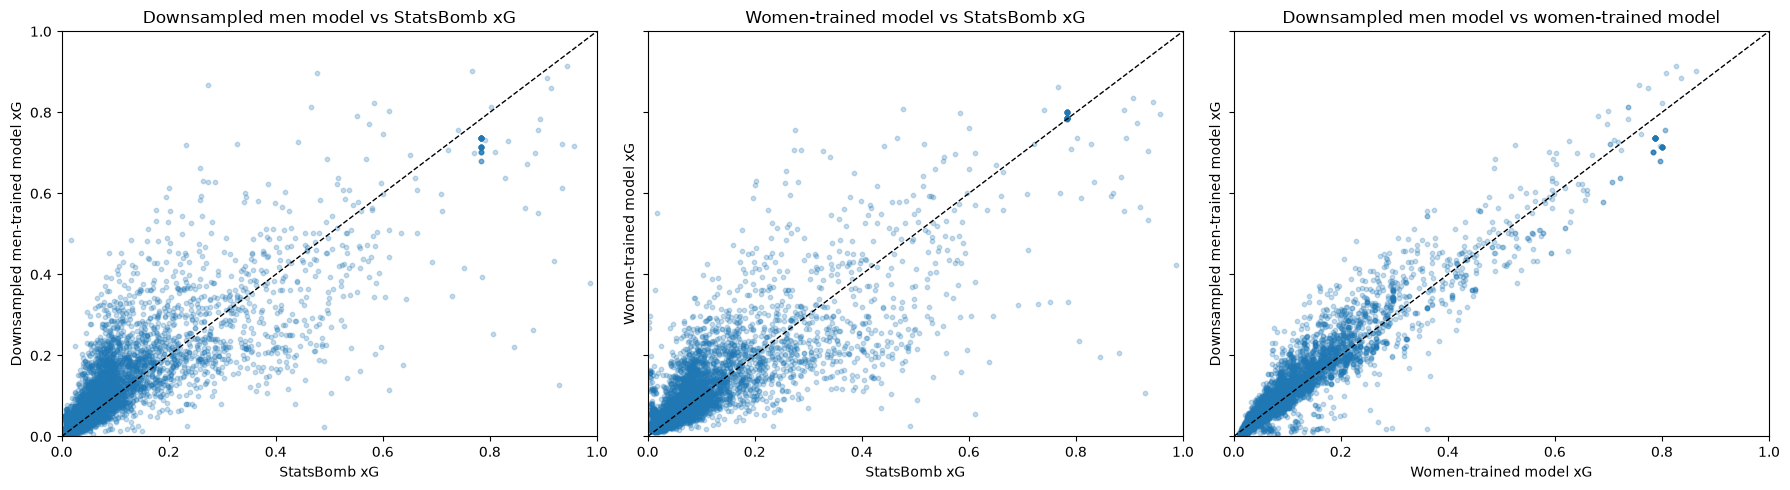

In [6]:
statsbomb_comparison_shots = xg_predictions.dropna(subset=["statsbomb_xg"]).copy()
if statsbomb_comparison_shots.empty:
    raise ValueError("No non-missing StatsBomb xG values found in the women test shots.")

prediction_columns = {
    "men_downsampled_trained_model": "men_downsampled_model_xg",
    "women_trained_model": "women_model_xg",
    "statsbomb_xg": "statsbomb_xg",
}

comparison_rows = []
for label, column in prediction_columns.items():
    prediction = statsbomb_comparison_shots[column]
    statsbomb_xg = statsbomb_comparison_shots["statsbomb_xg"]
    goals = statsbomb_comparison_shots["goal"]

    comparison_rows.append({
        "source": label,
        "shots": len(statsbomb_comparison_shots),
        "total_xg": prediction.sum(),
        "mean_xg": prediction.mean(),
        "mae_vs_statsbomb_xg": np.mean(np.abs(prediction - statsbomb_xg)),
        "rmse_vs_statsbomb_xg": np.sqrt(np.mean((prediction - statsbomb_xg) ** 2)),
        "pearson_vs_statsbomb_xg": prediction.corr(statsbomb_xg, method="pearson"),
        "spearman_vs_statsbomb_xg": prediction.corr(statsbomb_xg, method="spearman"),
        "brier_vs_goal": np.mean((prediction - goals) ** 2),
    })

print("指标说明：")
print("- source: 这一行对应的 xG 来源")
print("- shots: 参与比较的女足测试集射门数")
print("- total_xg: 这些射门的 xG 总和，用来看整体尺度/校准")
print("- mean_xg: 平均每脚射门的 xG")
print("- mae_vs_statsbomb_xg: 和 StatsBomb xG 的平均绝对差，越低越接近")
print("- rmse_vs_statsbomb_xg: 平方误差版本，更惩罚大的分歧")
print("- pearson_vs_statsbomb_xg: 和 StatsBomb xG 数值的线性相关")
print("- spearman_vs_statsbomb_xg: 和 StatsBomb xG 射门质量排序的相关")
print("- brier_vs_goal: 和实际进球结果 0/1 的均方误差，越低越好")
print()

model_vs_statsbomb_xg = pd.DataFrame(comparison_rows)
display(model_vs_statsbomb_xg.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
scatter_specs = [
    (
        "statsbomb_xg",
        "men_downsampled_model_xg",
        "StatsBomb xG",
        "Downsampled men-trained model xG",
        "Downsampled men model vs StatsBomb xG",
    ),
    (
        "statsbomb_xg",
        "women_model_xg",
        "StatsBomb xG",
        "Women-trained model xG",
        "Women-trained model vs StatsBomb xG",
    ),
    (
        "women_model_xg",
        "men_downsampled_model_xg",
        "Women-trained model xG",
        "Downsampled men-trained model xG",
        "Downsampled men model vs women-trained model",
    ),
]

max_xg = statsbomb_comparison_shots[
    ["statsbomb_xg", "men_downsampled_model_xg", "women_model_xg"]
].max().max()
axis_limit = min(1.0, max_xg * 1.05)

for axis, (x_column, y_column, x_label, y_label, title) in zip(axes, scatter_specs):
    axis.scatter(
        statsbomb_comparison_shots[x_column],
        statsbomb_comparison_shots[y_column],
        alpha=0.25,
        s=10,
    )
    axis.plot([0, axis_limit], [0, axis_limit], linestyle="--", color="black", linewidth=1)
    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    axis.set_xlim(0, axis_limit)
    axis.set_ylim(0, axis_limit)

plt.tight_layout()
plt.show()

## 7. 补充诊断：男足 full set 和 downsized 的差异

比较男足 full 模型、男足 downsampled 模型和女足模型在同一批女足 test shots 上的预测差异。


,comparison,left_column,right_column,mae_between_predictions,rmse_between_predictions,pearson_between_predictions,spearman_between_predictions
0,men_full_vs_men_downsampled,men_full_model_xg,men_downsampled_model_xg,0.0122,0.0202,0.9881,0.9856
1,men_full_vs_women,men_full_model_xg,women_model_xg,0.0211,0.0358,0.9638,0.9561
2,men_downsampled_vs_women,men_downsampled_model_xg,women_model_xg,0.0240,0.0393,0.9555,0.9467


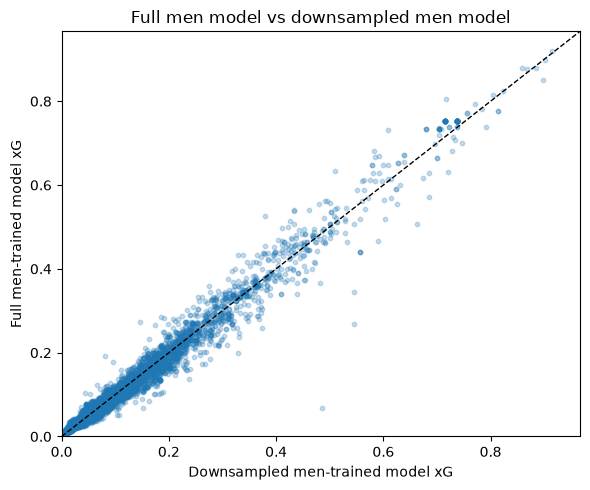

In [7]:
training_size_comparison_rows = []
comparison_pairs = [
    ("men_full_vs_men_downsampled", "men_full_model_xg", "men_downsampled_model_xg"),
    ("men_full_vs_women", "men_full_model_xg", "women_model_xg"),
    ("men_downsampled_vs_women", "men_downsampled_model_xg", "women_model_xg"),
]

for label, left_column, right_column in comparison_pairs:
    left = xg_predictions[left_column]
    right = xg_predictions[right_column]
    training_size_comparison_rows.append({
        "comparison": label,
        "left_column": left_column,
        "right_column": right_column,
        "mae_between_predictions": np.mean(np.abs(left - right)),
        "rmse_between_predictions": np.sqrt(np.mean((left - right) ** 2)),
        "pearson_between_predictions": left.corr(right, method="pearson"),
        "spearman_between_predictions": left.corr(right, method="spearman"),
    })

training_size_comparison = pd.DataFrame(training_size_comparison_rows)
display(training_size_comparison.round(4))

fig, axis = plt.subplots(figsize=(6, 5))
max_xg = xg_predictions[["men_full_model_xg", "men_downsampled_model_xg"]].max().max()
axis_limit = min(1.0, max_xg * 1.05)

axis.scatter(
    xg_predictions["men_downsampled_model_xg"],
    xg_predictions["men_full_model_xg"],
    alpha=0.25,
    s=10,
)
axis.plot([0, axis_limit], [0, axis_limit], linestyle="--", color="black", linewidth=1)
axis.set_title("Full men model vs downsampled men model")
axis.set_xlabel("Downsampled men-trained model xG")
axis.set_ylabel("Full men-trained model xG")
axis.set_xlim(0, axis_limit)
axis.set_ylim(0, axis_limit)

plt.tight_layout()
plt.show()

## 8. 查看原始 `competition_events` 输出

保留原 notebook 的检查 cell，用来查看 StatsBomb `competition_events` 返回的原始字段。


In [8]:
example_competition = WOMEN_COMPETITIONS[0]

example_matches = sb.matches(
    competition_id=example_competition["competition_id"],
    season_id=example_competition["season_id"],
)
print("sb.matches(...) shape:", example_matches.shape)
print("sb.matches(...) columns:")
print(example_matches.columns.tolist())

print("\nOne sb.matches(...) row:")
display(example_matches.head(1).T.rename(columns={example_matches.index[0]: "value"}))

example_competition_shots = sb.competition_events(
    country=example_competition["country"],
    division=example_competition["division"],
    season=example_competition["season"],
    gender=example_competition["gender"],
    filters={"type": "Shot"},
)
print("\nsb.competition_events(..., filters={'type': 'Shot'}) shape:", example_competition_shots.shape)
print("sb.competition_events(...) columns:")
print(example_competition_shots.columns.tolist())

shot_debug_columns = [
    "match_id",
    "minute",
    "second",
    "team",
    "player",
    "player_id",
    "position",
    "location",
    "play_pattern",
    "shot_type",
    "shot_body_part",
    "shot_technique",
    "shot_first_time",
    "under_pressure",
    "shot_outcome",
    "shot_statsbomb_xg",
]
shot_debug_columns = [column for column in shot_debug_columns if column in example_competition_shots.columns]

print("\nRaw shot rows from competition_events:")
display(example_competition_shots[shot_debug_columns].head(10))

print("\n当前 notebook 的 xG modeling rows 来自 xg_data 读取的 cached shot table；这里不再复刻旧的 event_to_xg_row helper。")
print("Cached women shot columns:")
print(women_shots.columns.tolist())
display(women_shots.head(10))


sb.matches(...) shape: (132, 55)
sb.matches(...) columns:
['match_id', 'match_date', 'kick_off', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'match_week', 'competition_id', 'competition_country_name', 'competition_name', 'competition', 'season_id', 'season', 'home_team_id', 'home_team', 'home_team_gender', 'home_team_group', 'home_team_country_id', 'home_team_country_name', 'away_team_id', 'away_team', 'away_team_gender', 'away_team_group', 'away_team_country_id', 'away_team_country_name', 'competition_stage_id', 'competition_stage', 'stadium_id', 'stadium', 'stadium_country_id', 'stadium_country_name', 'referee_id', 'referee', 'referee_country_id', 'referee_country_name', 'home_managers', 'away_managers', 'home_manager_id', 'home_manager_name', 'home_manager_nickname', 'home_manager_dob', 'home_manager_country_id', 'home_manager_country_name', 'away_manager_id', 'away_manager_name', 'away_manager_nickname', 'away_manager_dob', 'a

,value
match_id,3913082
match_date,2023-11-05
kick_off,18:45:00.000
home_score,2
away_score,2
match_status,available
match_status_360,unscheduled
last_updated,2026-04-11T13:03:17.779673
last_updated_360,None
match_week,5



sb.competition_events(..., filters={'type': 'Shot'}) shape: (3529, 39)
sb.competition_events(...) columns:
['duration', 'id', 'index', 'location', 'match_id', 'minute', 'off_camera', 'out', 'period', 'play_pattern', 'player', 'player_id', 'position', 'possession', 'possession_team', 'possession_team_id', 'related_events', 'second', 'shot_aerial_won', 'shot_body_part', 'shot_deflected', 'shot_end_location', 'shot_first_time', 'shot_freeze_frame', 'shot_key_pass_id', 'shot_one_on_one', 'shot_open_goal', 'shot_outcome', 'shot_redirect', 'shot_saved_off_target', 'shot_saved_to_post', 'shot_statsbomb_xg', 'shot_technique', 'shot_type', 'team', 'team_id', 'timestamp', 'type', 'under_pressure']

Raw shot rows from competition_events:


,match_id,minute,second,team,player,player_id,position,location,play_pattern,shot_type,shot_body_part,shot_technique,shot_first_time,under_pressure,shot_outcome,shot_statsbomb_xg
0,3913082,0,54,Manchester United W,Leah Galton,31539,Left Wing,"[112.1, 36.3]",From Kick Off,Open Play,Head,Normal,NaN,True,Blocked,0.080485
1,3913082,2,29,Manchester United W,Ella Toone,31534,Left Center Midfield,"[103.2, 34.0]",From Throw In,Open Play,Right Foot,Normal,NaN,NaN,Blocked,0.032564
2,3913082,2,32,Manchester United W,Hinata Miyazawa,401932,Right Center Midfield,"[97.4, 44.4]",From Throw In,Open Play,Right Foot,Normal,NaN,NaN,Blocked,0.039369
3,3913082,2,33,Manchester United W,Melvine Malard,31614,Right Wing,"[107.7, 38.8]",From Throw In,Open Play,Left Foot,Normal,True,True,Saved,0.269035
4,3913082,7,12,Manchester United W,Geyse da Silva Ferreira,25543,Center Forward,"[115.5, 53.9]",Regular Play,Open Play,Right Foot,Normal,NaN,NaN,Off T,0.015162
5,3913082,18,1,Brighton & Hove Albion WFC,Madison Haley,405188,Right Wing,"[114.9, 42.6]",From Corner,Open Play,Head,Normal,NaN,True,Blocked,0.124237
6,3913082,18,15,Brighton & Hove Albion WFC,Elisabeth Terland,276301,Center Forward,"[105.7, 42.2]",From Corner,Open Play,Right Foot,Normal,True,NaN,Saved,0.108810
7,3913082,20,18,Brighton & Hove Albion WFC,Jorelyn Andrea Daniela Carabalí Martínez,388473,Left Center Back,"[111.5, 37.3]",From Corner,Open Play,Head,Normal,NaN,True,Saved,0.065711
8,3913082,27,48,Brighton & Hove Albion WFC,Elisabeth Terland,276301,Center Forward,"[102.8, 31.3]",From Free Kick,Open Play,Right Foot,Half Volley,True,NaN,Off T,0.086174
9,3913082,29,25,Brighton & Hove Albion WFC,Maisie Symonds,85004,Left Defensive Midfield,"[101.5, 52.6]",From Counter,Open Play,Right Foot,Normal,NaN,NaN,Wayward,0.042489



当前 notebook 的 xG modeling rows 来自 xg_data 读取的 cached shot table；这里不再复刻旧的 event_to_xg_row helper。
Cached women shot columns:
['game_id', 'player_id', 'league', 'shot_x', 'shot_y', 'distance', 'angle', 'body_part', 'shot_technique', 'shot_type', 'play_pattern', 'shot_context', 'under_pressure', 'first_time', 'statsbomb_xg', 'goal']


,game_id,player_id,league,shot_x,shot_y,distance,angle,body_part,shot_technique,shot_type,play_pattern,shot_context,under_pressure,first_time,statsbomb_xg,goal
0,3913082,31539,WSL,112.1,36.3,7.594319,0.851927,Head,Normal,Open Play,From Kick Off,Set Piece,True,False,0.080485,0
1,3913082,31534,WSL,103.2,34.0,15.559563,0.439765,Right Foot,Normal,Open Play,From Throw In,Set Piece,False,False,0.032564,0
2,3913082,401932,WSL,97.4,44.4,20.125561,0.354032,Right Foot,Normal,Open Play,From Throw In,Set Piece,False,False,0.039369,0
3,3913082,31614,WSL,107.7,38.8,10.810726,0.650725,Left Foot,Normal,Open Play,From Throw In,Set Piece,True,True,0.269035,0
4,3913082,25543,WSL,115.5,53.9,12.453840,0.200664,Right Foot,Normal,Open Play,Regular Play,Open Play,False,False,0.015162,0
5,3913082,405188,WSL,114.9,42.6,4.979760,1.234954,Head,Normal,Open Play,From Corner,Set Piece,True,False,0.124237,0
6,3913082,276301,WSL,105.7,42.2,12.651465,0.558239,Right Foot,Normal,Open Play,From Corner,Set Piece,False,True,0.108810,0
7,3913082,388473,WSL,111.5,37.3,7.783536,0.856660,Head,Normal,Open Play,From Corner,Set Piece,True,False,0.065711,0
8,3913082,276301,WSL,102.8,31.3,16.768677,0.390282,Right Foot,Half Volley,Open Play,From Free Kick,Free Kick,False,True,0.086174,0
9,3913082,85004,WSL,101.5,52.6,19.409772,0.315242,Right Foot,Normal,Open Play,From Counter,Open Play,False,False,0.042489,0


## 9. 按射门位置 grid 比较男足 xG 和女足 xG 的打分差异

把女足 test shots 按射门位置落到 12x16 grid，汇总 `men_downsampled_model_xg - women_model_xg` 的空间分布。


In [9]:
XG_GRID_ROWS = 12
XG_GRID_COLS = 16
MIN_GRID_SHOTS = 10
STATSBOMB_PITCH_LENGTH = 120.0
STATSBOMB_PITCH_WIDTH = 80.0


def add_xg_grid_columns(shots, rows=XG_GRID_ROWS, cols=XG_GRID_COLS):
    """Assign each shot to a StatsBomb-coordinate pitch grid cell."""
    shots = shots.copy()
    shot_x = pd.to_numeric(shots["shot_x"], errors="coerce")
    shot_y = pd.to_numeric(shots["shot_y"], errors="coerce")

    clipped_x = np.clip(shot_x, 0, np.nextafter(STATSBOMB_PITCH_LENGTH, 0))
    clipped_y = np.clip(shot_y, 0, np.nextafter(STATSBOMB_PITCH_WIDTH, 0))

    shots["grid_col"] = np.floor(clipped_x / STATSBOMB_PITCH_LENGTH * cols).astype("Int64")
    shots["grid_row"] = np.floor(clipped_y / STATSBOMB_PITCH_WIDTH * rows).astype("Int64")

    cell_width = STATSBOMB_PITCH_LENGTH / cols
    cell_height = STATSBOMB_PITCH_WIDTH / rows
    shots["grid_x_min"] = shots["grid_col"].astype(float) * cell_width
    shots["grid_x_max"] = shots["grid_x_min"] + cell_width
    shots["grid_y_min"] = shots["grid_row"].astype(float) * cell_height
    shots["grid_y_max"] = shots["grid_y_min"] + cell_height
    return shots


def summarize_xg_delta_by_grid(
    predictions,
    men_column="men_downsampled_model_xg",
    women_column="women_model_xg",
    rows=XG_GRID_ROWS,
    cols=XG_GRID_COLS,
):
    """Summarize men-vs-women xG prediction deltas inside each shot-location grid."""
    grid_predictions = add_xg_grid_columns(predictions, rows=rows, cols=cols)
    grid_predictions = grid_predictions.dropna(subset=["grid_row", "grid_col", men_column, women_column]).copy()
    grid_predictions["xg_delta"] = grid_predictions[men_column] - grid_predictions[women_column]

    grid_summary = (
        grid_predictions.groupby(["grid_row", "grid_col"], observed=True)
        .agg(
            shot_count=("xg_delta", "size"),
            aggregate_delta=("xg_delta", "sum"),
            mean_delta=("xg_delta", "mean"),
            delta_std=("xg_delta", "std"),
            mean_men_xg=(men_column, "mean"),
            mean_women_xg=(women_column, "mean"),
        )
        .reset_index()
    )

    all_cells = pd.MultiIndex.from_product(
        [range(rows), range(cols)],
        names=["grid_row", "grid_col"],
    ).to_frame(index=False)
    grid_summary = all_cells.merge(grid_summary, on=["grid_row", "grid_col"], how="left")
    grid_summary["shot_count"] = grid_summary["shot_count"].fillna(0).astype(int)
    grid_summary["aggregate_delta"] = grid_summary["aggregate_delta"].fillna(0)
    grid_summary["delta_std"] = grid_summary["delta_std"].fillna(0)

    cell_width = STATSBOMB_PITCH_LENGTH / cols
    cell_height = STATSBOMB_PITCH_WIDTH / rows
    grid_summary["grid_x_min"] = grid_summary["grid_col"] * cell_width
    grid_summary["grid_x_max"] = grid_summary["grid_x_min"] + cell_width
    grid_summary["grid_y_min"] = grid_summary["grid_row"] * cell_height
    grid_summary["grid_y_max"] = grid_summary["grid_y_min"] + cell_height
    grid_summary["grid_label"] = (
        "r" + grid_summary["grid_row"].astype(str)
        + "_c" + grid_summary["grid_col"].astype(str)
    )
    return grid_predictions, grid_summary


xg_grid_predictions, xg_grid_delta_summary = summarize_xg_delta_by_grid(xg_predictions)

print("Grid delta definition: men_downsampled_model_xg - women_model_xg")
print(f"women test shots assigned to grid: {len(xg_grid_predictions):,} of {len(xg_predictions):,}")
valid_grid_mask = xg_grid_delta_summary["shot_count"] >= MIN_GRID_SHOTS
valid_xg_grid_delta_summary = xg_grid_delta_summary[valid_grid_mask].copy()

print(f"non-empty grid cells: {(xg_grid_delta_summary.shot_count > 0).sum()} of {len(xg_grid_delta_summary)}")
print(f"grid cells with at least {MIN_GRID_SHOTS} shots: {valid_grid_mask.sum()} of {len(xg_grid_delta_summary)}")

print("\nMost common shot grids in women test set:")
display(
    valid_xg_grid_delta_summary
    .sort_values("shot_count", ascending=False)
    .head(15)
    .round(4)
)

print("\nLargest absolute aggregate deltas by grid:")
display(
    valid_xg_grid_delta_summary
    .assign(abs_aggregate_delta=lambda frame: frame["aggregate_delta"].abs())
    .sort_values("abs_aggregate_delta", ascending=False)
    .head(15)
    .round(4)
)


Grid delta definition: men_downsampled_model_xg - women_model_xg
women test shots assigned to grid: 5,965 of 5,965
non-empty grid cells: 73 of 192
grid cells with at least 10 shots: 40 of 192

Most common shot grids in women test set:


,grid_row,grid_col,shot_count,aggregate_delta,mean_delta,delta_std,mean_men_xg,mean_women_xg,grid_x_min,grid_x_max,grid_y_min,grid_y_max,grid_label
110,6,14,599,8.5789,0.0143,0.0488,0.2165,0.2022,105.0,112.5,40.0000,46.6667,r6_c14
94,5,14,502,9.3627,0.0187,0.0427,0.1638,0.1451,105.0,112.5,33.3333,40.0000,r5_c14
95,5,15,370,6.3943,0.0173,0.0647,0.2940,0.2768,112.5,120.0,33.3333,40.0000,r5_c15
78,4,14,344,4.3979,0.0128,0.0322,0.1324,0.1197,105.0,112.5,26.6667,33.3333,r4_c14
111,6,15,339,5.7453,0.0169,0.0694,0.3081,0.2912,112.5,120.0,40.0000,46.6667,r6_c15
109,6,13,326,2.6820,0.0082,0.0287,0.0949,0.0867,97.5,105.0,40.0000,46.6667,r6_c13
126,7,14,324,6.7319,0.0208,0.0312,0.1393,0.1185,105.0,112.5,46.6667,53.3333,r7_c14
77,4,13,277,1.3774,0.0050,0.0234,0.0621,0.0571,97.5,105.0,26.6667,33.3333,r4_c13
93,5,13,273,2.2542,0.0083,0.0282,0.0952,0.0869,97.5,105.0,33.3333,40.0000,r5_c13
125,7,13,265,1.8490,0.0070,0.0177,0.0635,0.0566,97.5,105.0,46.6667,53.3333,r7_c13



Largest absolute aggregate deltas by grid:


,grid_row,grid_col,shot_count,aggregate_delta,mean_delta,delta_std,mean_men_xg,mean_women_xg,grid_x_min,grid_x_max,grid_y_min,grid_y_max,grid_label,abs_aggregate_delta
94,5,14,502,9.3627,0.0187,0.0427,0.1638,0.1451,105.0,112.5,33.3333,40.0000,r5_c14,9.3627
110,6,14,599,8.5789,0.0143,0.0488,0.2165,0.2022,105.0,112.5,40.0000,46.6667,r6_c14,8.5789
126,7,14,324,6.7319,0.0208,0.0312,0.1393,0.1185,105.0,112.5,46.6667,53.3333,r7_c14,6.7319
95,5,15,370,6.3943,0.0173,0.0647,0.2940,0.2768,112.5,120.0,33.3333,40.0000,r5_c15,6.3943
111,6,15,339,5.7453,0.0169,0.0694,0.3081,0.2912,112.5,120.0,40.0000,46.6667,r6_c15,5.7453
78,4,14,344,4.3979,0.0128,0.0322,0.1324,0.1197,105.0,112.5,26.6667,33.3333,r4_c14,4.3979
127,7,15,159,2.8254,0.0178,0.0297,0.1111,0.0933,112.5,120.0,46.6667,53.3333,r7_c15,2.8254
109,6,13,326,2.6820,0.0082,0.0287,0.0949,0.0867,97.5,105.0,40.0000,46.6667,r6_c13,2.6820
79,4,15,157,2.6533,0.0169,0.0362,0.1200,0.1031,112.5,120.0,26.6667,33.3333,r4_c15,2.6533
93,5,13,273,2.2542,0.0083,0.0282,0.0952,0.0869,97.5,105.0,33.3333,40.0000,r5_c13,2.2542


## 10. 2D pitch visualization

左图看女足测试集射门位置分布，右图看每个射门区域的平均模型差异。


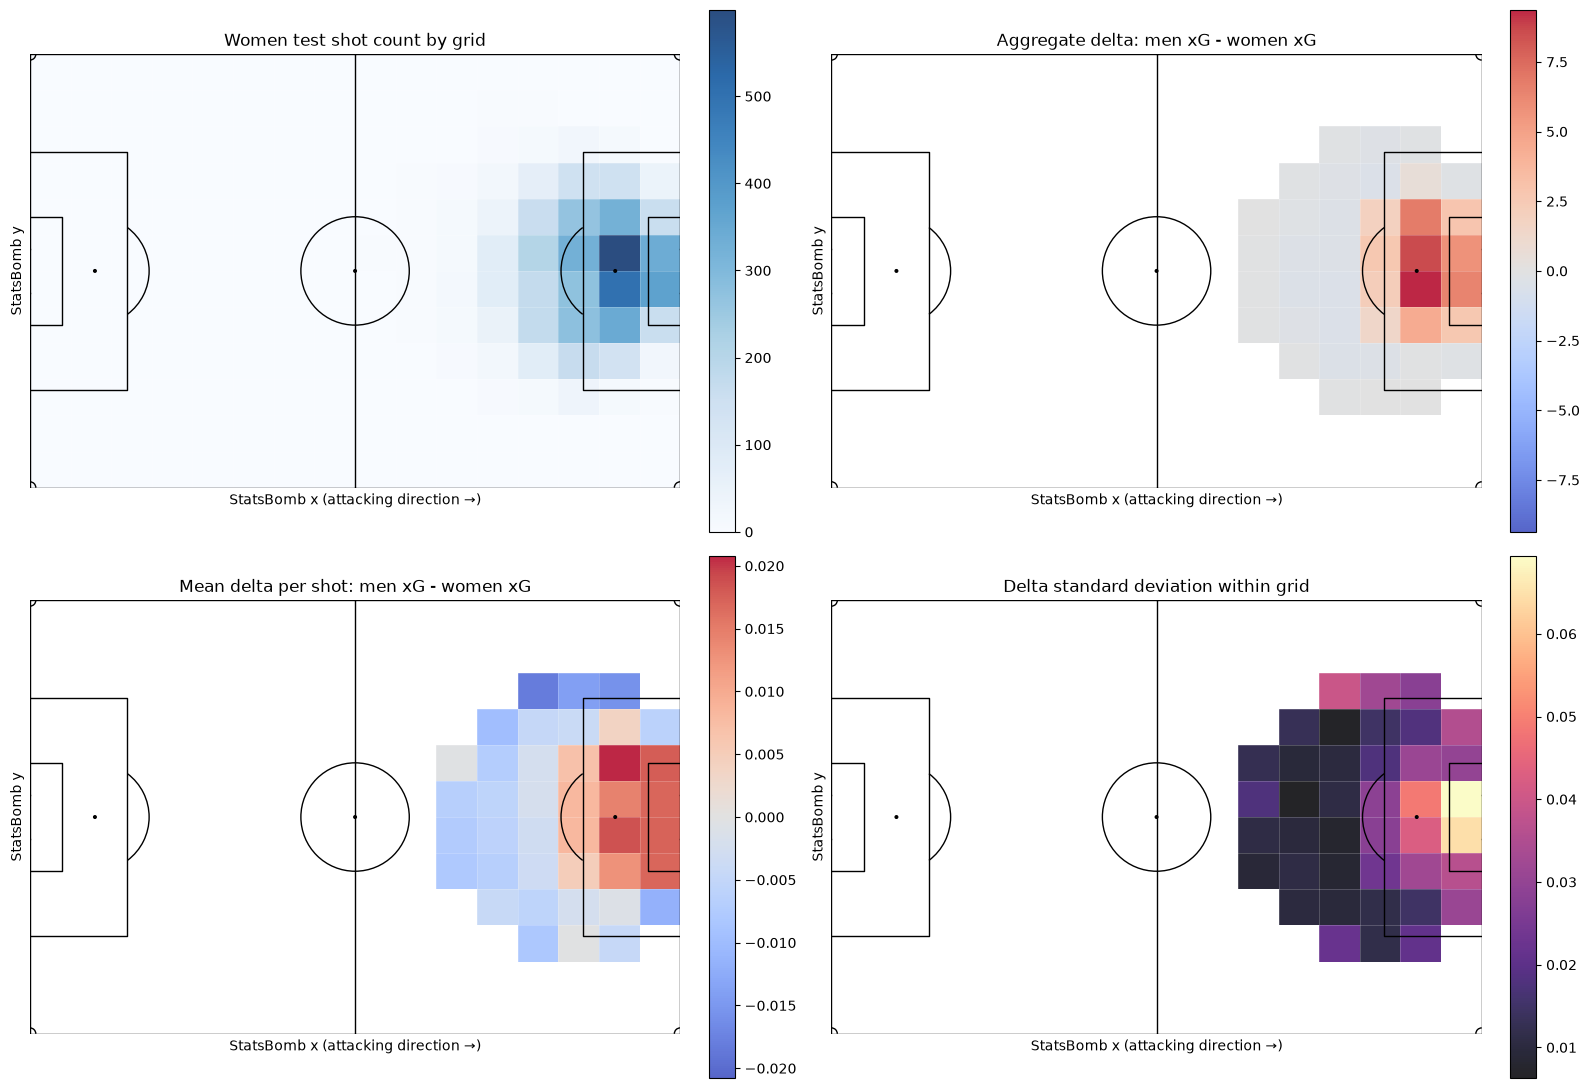

In [10]:
def grid_metric_matrix(grid_summary, metric, rows=XG_GRID_ROWS, cols=XG_GRID_COLS):
    """Convert a grid summary column into a rows x cols matrix for imshow."""
    matrix = np.full((rows, cols), np.nan)
    for row in grid_summary.itertuples(index=False):
        value = getattr(row, metric)
        matrix[int(row.grid_row), int(row.grid_col)] = value
    return matrix


def mask_low_sample_grids(grid_summary, min_shots=MIN_GRID_SHOTS):
    """Return a copy where metric columns are hidden for low-sample grid cells."""
    grid_summary = grid_summary.copy()
    low_sample_mask = grid_summary["shot_count"] < min_shots
    metric_columns = ["aggregate_delta", "mean_delta", "delta_std", "mean_men_xg", "mean_women_xg"]
    grid_summary.loc[low_sample_mask, metric_columns] = np.nan
    return grid_summary


def plot_xg_grid_heatmap(axis, grid_summary, metric, title, cmap="viridis", center_zero=False):
    """Plot one grid metric over a StatsBomb pitch."""
    matrix = grid_metric_matrix(grid_summary, metric)
    matrix = np.ma.masked_invalid(matrix)

    vmin = vmax = None
    if center_zero:
        max_abs_value = np.nanmax(np.abs(matrix.filled(np.nan)))
        if np.isfinite(max_abs_value) and max_abs_value > 0:
            vmin = -max_abs_value
            vmax = max_abs_value

    colormap = plt.get_cmap(cmap).copy()
    colormap.set_bad(color="white", alpha=0.0)

    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color="white",
        line_color="black",
        linewidth=1.0,
        line_zorder=3,
        goal_type="box",
        corner_arcs=True,
    )
    pitch.draw(ax=axis)

    image = axis.imshow(
        matrix,
        origin="lower",
        extent=[0, STATSBOMB_PITCH_LENGTH, 0, STATSBOMB_PITCH_WIDTH],
        aspect="equal",
        cmap=colormap,
        vmin=vmin,
        vmax=vmax,
        interpolation="none",
        alpha=0.86,
        zorder=1,
    )

    for x_value in np.linspace(0, STATSBOMB_PITCH_LENGTH, XG_GRID_COLS + 1):
        axis.plot([x_value, x_value], [0, STATSBOMB_PITCH_WIDTH], color="white", alpha=0.35, linewidth=0.4, zorder=2)
    for y_value in np.linspace(0, STATSBOMB_PITCH_WIDTH, XG_GRID_ROWS + 1):
        axis.plot([0, STATSBOMB_PITCH_LENGTH], [y_value, y_value], color="white", alpha=0.35, linewidth=0.4, zorder=2)

    axis.set_title(title)
    axis.set_xlabel("StatsBomb x (attacking direction →)")
    axis.set_ylabel("StatsBomb y")
    axis.set_xlim(0, STATSBOMB_PITCH_LENGTH)
    axis.set_ylim(0, STATSBOMB_PITCH_WIDTH)
    axis.set_aspect("equal", adjustable="box")
    plt.colorbar(image, ax=axis, fraction=0.046, pad=0.04)


plot_grid_summary = mask_low_sample_grids(xg_grid_delta_summary)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

plot_xg_grid_heatmap(
    axes[0, 0],
    plot_grid_summary,
    "shot_count",
    "Women test shot count by grid",
    cmap="Blues",
)
plot_xg_grid_heatmap(
    axes[0, 1],
    plot_grid_summary,
    "aggregate_delta",
    "Aggregate delta: men xG - women xG",
    cmap="coolwarm",
    center_zero=True,
)
plot_xg_grid_heatmap(
    axes[1, 0],
    plot_grid_summary,
    "mean_delta",
    "Mean delta per shot: men xG - women xG",
    cmap="coolwarm",
    center_zero=True,
)
plot_xg_grid_heatmap(
    axes[1, 1],
    plot_grid_summary,
    "delta_std",
    "Delta standard deviation within grid",
    cmap="magma",
)

plt.tight_layout()
plt.show()


## 11. 按球员主要位置 bucket 比较男足 xG 和女足 xG 的排名影响

按 position bucket 汇总球员 xG 排名差异，观察模型差异是否集中在某些位置组。


In [11]:
POSITION_CACHE_CANDIDATES = [
    CACHE_DIR / "women_positions_competition_events_method.pkl",
    CACHE_DIR / "women_positions_statsbombpy_remote.pkl",
]

MIN_PLAYERS_FOR_BUCKET_SPEARMAN = 2


def load_women_position_rows():
    """Load cached women player-position observations."""
    for position_cache in POSITION_CACHE_CANDIDATES:
        if position_cache.exists():
            print(f"[cache] women positions: {position_cache}")
            positions = pd.read_pickle(position_cache).copy()
            break
    else:
        raise FileNotFoundError(
            "No women position cache found. Run the position-loading notebook/cell first, "
            "or create vaep_data/women_positions_competition_events_method.pkl."
        )

    required_columns = {"player_id", "position_name"}
    missing_columns = required_columns.difference(positions.columns)
    if missing_columns:
        raise ValueError(f"Position cache missing columns: {sorted(missing_columns)}")

    positions = positions[list(required_columns)].dropna().copy()
    positions["player_id_key"] = pd.to_numeric(positions["player_id"], errors="coerce").astype("Int64")
    positions["position_name"] = positions["position_name"].astype(str)
    positions = positions.dropna(subset=["player_id_key", "position_name"])
    return positions


def build_primary_position_table(position_rows):
    """Choose the most frequent observed position for each player."""
    position_counts = (
        position_rows.groupby(["player_id_key", "position_name"])
        .size()
        .reset_index(name="position_observations")
        .sort_values(["player_id_key", "position_observations", "position_name"], ascending=[True, False, True])
    )

    primary_positions = (
        position_counts.groupby("player_id_key", as_index=False)
        .first()
        .rename(columns={"position_name": "primary_position"})
    )
    return primary_positions


def bucket_position(position_name):
    """Map granular StatsBomb positions to broad tactical buckets."""
    position_name = str(position_name)

    if "Goalkeeper" in position_name:
        return "Goalkeeper"
    if "Center Back" in position_name:
        return "Center Back"
    if "Wing Back" in position_name or position_name in {"Left Back", "Right Back"}:
        return "Fullback / Wing Back"
    if "Defensive Midfield" in position_name:
        return "Defensive Midfield"
    if "Center Midfield" in position_name:
        return "Central Midfield"
    if "Attacking Midfield" in position_name:
        return "Attacking Midfield"
    if position_name in {"Left Midfield", "Right Midfield", "Left Wing", "Right Wing"}:
        return "Wide Midfielder / Winger"
    if "Center Forward" in position_name or position_name == "Striker":
        return "Forward"
    return "Other / Unknown"


def spearman_if_available(left, right, min_players=MIN_PLAYERS_FOR_BUCKET_SPEARMAN):
    """Return Spearman correlation when there are enough non-constant players."""
    if len(left) < min_players:
        return np.nan
    if left.nunique(dropna=True) < 2 or right.nunique(dropna=True) < 2:
        return np.nan
    return stats.spearmanr(left, right)[0]


women_position_rows = load_women_position_rows()
primary_positions = build_primary_position_table(women_position_rows)
primary_positions["position_bucket"] = primary_positions["primary_position"].map(bucket_position)

player_xg_by_position = player_xg_comparison.copy()
player_xg_by_position["player_id_key"] = pd.to_numeric(
    player_xg_by_position["player_id"],
    errors="coerce",
).astype("Int64")

player_xg_by_position = player_xg_by_position.merge(
    primary_positions,
    on="player_id_key",
    how="left",
)
player_xg_by_position["primary_position"] = player_xg_by_position["primary_position"].fillna("Unknown")
player_xg_by_position["position_bucket"] = player_xg_by_position["position_bucket"].fillna("Other / Unknown")
player_xg_by_position["xg_delta"] = (
    player_xg_by_position["men_downsampled_xg"] - player_xg_by_position["women_xg"]
)
player_xg_by_position["abs_xg_delta"] = player_xg_by_position["xg_delta"].abs()

player_xg_by_position["bucket_men_rank"] = player_xg_by_position.groupby("position_bucket")[
    "men_downsampled_xg"
].rank(ascending=False, method="min")
player_xg_by_position["bucket_women_rank"] = player_xg_by_position.groupby("position_bucket")[
    "women_xg"
].rank(ascending=False, method="min")
player_xg_by_position["bucket_rank_delta"] = (
    player_xg_by_position["bucket_men_rank"] - player_xg_by_position["bucket_women_rank"]
)
player_xg_by_position["abs_bucket_rank_delta"] = player_xg_by_position["bucket_rank_delta"].abs()

bucket_summary_rows = []
for position_bucket, bucket_players in player_xg_by_position.groupby("position_bucket"):
    bucket_summary_rows.append(
        {
            "position_bucket": position_bucket,
            "players": len(bucket_players),
            "shots": int(bucket_players["shot_count"].sum()),
            "spearman_men_vs_women_xg": spearman_if_available(
                bucket_players["men_downsampled_xg"],
                bucket_players["women_xg"],
            ),
            "aggregate_xg_delta": bucket_players["xg_delta"].sum(),
            "mean_xg_delta": bucket_players["xg_delta"].mean(),
            "median_xg_delta": bucket_players["xg_delta"].median(),
            "mean_abs_xg_delta": bucket_players["abs_xg_delta"].mean(),
            "mean_bucket_rank_delta": bucket_players["bucket_rank_delta"].mean(),
            "median_abs_bucket_rank_delta": bucket_players["abs_bucket_rank_delta"].median(),
            "max_abs_bucket_rank_delta": bucket_players["abs_bucket_rank_delta"].max(),
        }
    )

position_bucket_xg_summary = (
    pd.DataFrame(bucket_summary_rows)
    .sort_values(["players", "shots"], ascending=False)
    .reset_index(drop=True)
)

print("Position-bucket summary for women test-set players with at least", MIN_SHOTS_PER_PLAYER, "shots:")
display(position_bucket_xg_summary.round(4))

print("\nPlayers with largest within-bucket rank changes:")
display(
    player_xg_by_position.sort_values("abs_bucket_rank_delta", ascending=False)[
        [
            "player_id",
            "primary_position",
            "position_bucket",
            "shot_count",
            "men_downsampled_xg",
            "women_xg",
            "xg_delta",
            "bucket_men_rank",
            "bucket_women_rank",
            "bucket_rank_delta",
        ]
    ]
    .head(25)
    .round(4)
)


[cache] women positions: vaep_data\women_positions_competition_events_method.pkl
Position-bucket summary for women test-set players with at least 10 shots:


,position_bucket,players,shots,spearman_men_vs_women_xg,aggregate_xg_delta,mean_xg_delta,median_xg_delta,mean_abs_xg_delta,mean_bucket_rank_delta,median_abs_bucket_rank_delta,max_abs_bucket_rank_delta
0,Forward,70,1137,0.9640,10.4652,0.1495,0.1350,0.1876,0.0,2.0,24.0
1,Wide Midfielder / Winger,63,987,0.9733,8.7609,0.1391,0.1181,0.1804,0.0,3.0,11.0
2,Defensive Midfield,24,329,0.9296,-0.3109,-0.0130,-0.0143,0.0877,0.0,1.0,8.0
3,Attacking Midfield,19,271,0.9860,1.9437,0.1023,0.0746,0.1249,0.0,0.0,2.0
4,Central Midfield,16,210,0.9412,0.8614,0.0538,0.0380,0.1130,0.0,1.0,4.0
5,Fullback / Wing Back,7,83,0.8571,-0.4008,-0.0573,-0.0262,0.0809,0.0,0.0,2.0



Players with largest within-bucket rank changes:


,player_id,primary_position,position_bucket,shot_count,men_downsampled_xg,women_xg,xg_delta,bucket_men_rank,bucket_women_rank,bucket_rank_delta
171,321541,Center Forward,Forward,16,2.6927,1.8458,0.8469,14.0,38.0,-24.0
194,409156,Right Center Forward,Forward,22,1.6104,1.8033,-0.1929,53.0,40.0,13.0
11,10143,Center Forward,Forward,12,2.0247,2.2771,-0.2524,36.0,23.0,13.0
144,106836,Right Wing,Wide Midfielder / Winger,13,1.2078,1.3881,-0.1803,46.0,35.0,11.0
196,409188,Left Center Forward,Forward,10,2.1216,2.2403,-0.1188,34.0,24.0,10.0
5,5055,Center Forward,Forward,25,2.6119,2.1553,0.4566,18.0,28.0,-10.0
65,32836,Right Midfield,Wide Midfielder / Winger,20,0.9976,1.0737,-0.0760,54.0,45.0,9.0
179,361405,Right Wing,Wide Midfielder / Winger,12,1.4552,1.1726,0.2827,34.0,43.0,-9.0
142,98043,Left Wing,Wide Midfielder / Winger,11,1.7504,1.4012,0.3492,25.0,34.0,-9.0
127,50366,Left Wing,Wide Midfielder / Winger,21,2.1973,2.6565,-0.4592,18.0,9.0,9.0


## 12. 按场上位置分类的 visualization

沿用原 notebook 的 position-bucket visualization，展示组内排名一致性和 xG delta 分布。


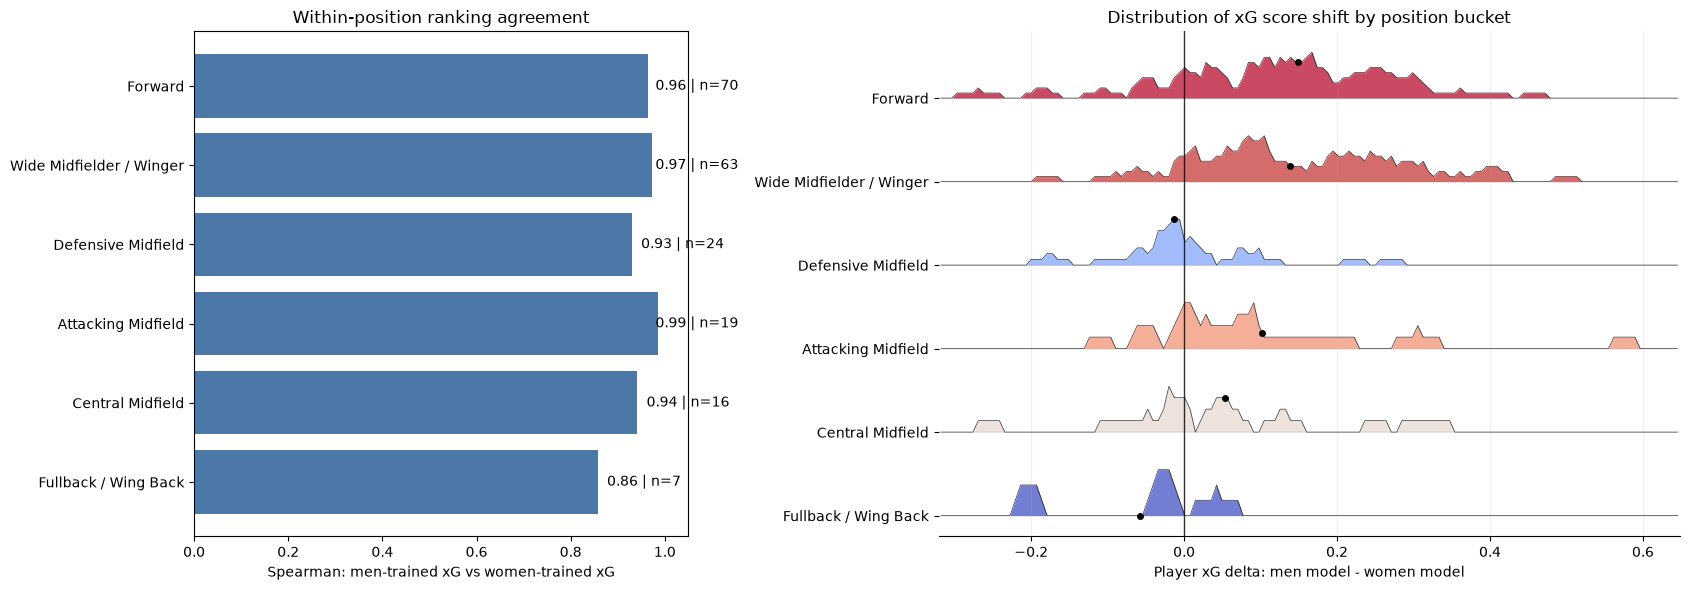

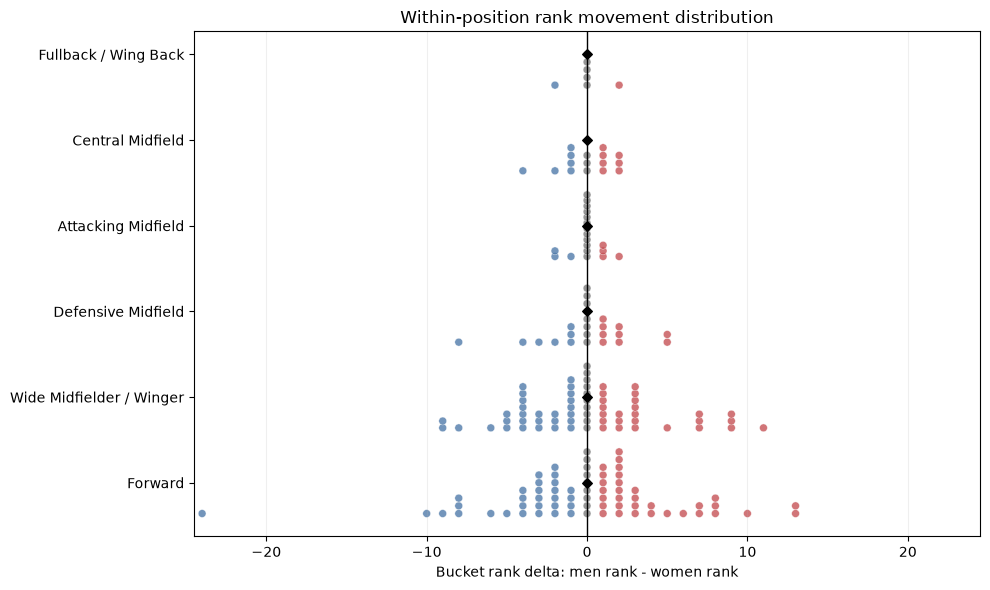

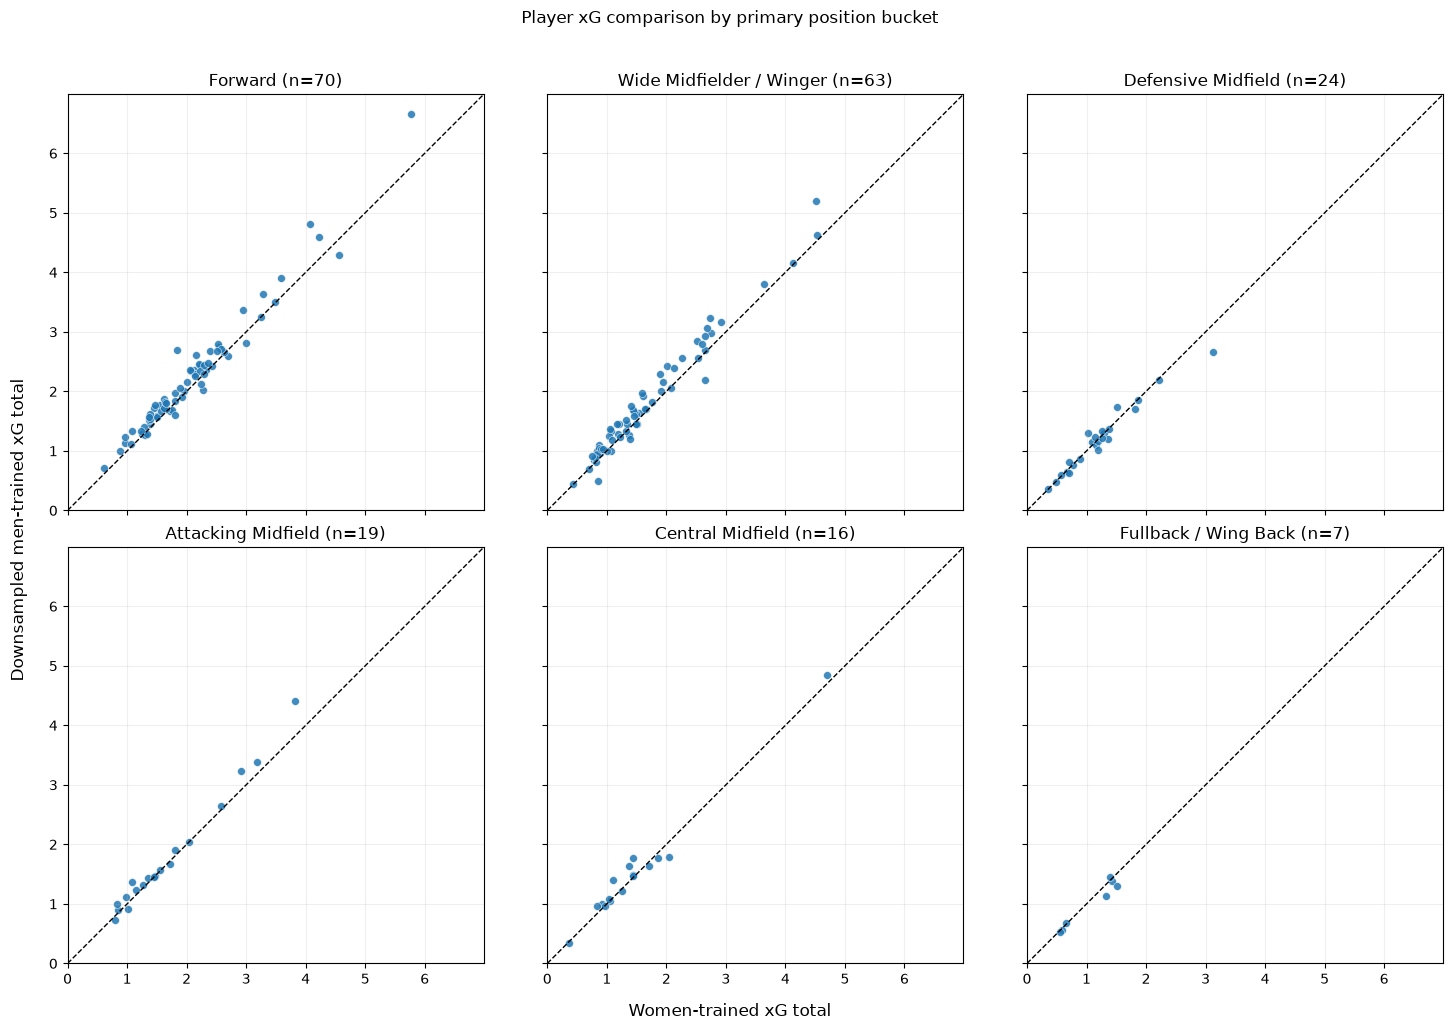

In [12]:
plot_bucket_summary = position_bucket_xg_summary.copy()
plot_bucket_summary = plot_bucket_summary.sort_values("players", ascending=True)
position_bucket_order = plot_bucket_summary["position_bucket"].tolist()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, max(6, 0.45 * len(position_bucket_order) + 2)),
    gridspec_kw={"width_ratios": [0.9, 1.35]},
)

axes[0].barh(
    plot_bucket_summary["position_bucket"],
    plot_bucket_summary["spearman_men_vs_women_xg"],
    color="#4C78A8",
)
axes[0].set_xlim(0, 1.05)
axes[0].set_xlabel("Spearman: men-trained xG vs women-trained xG")
axes[0].set_title("Within-position ranking agreement")
for y_index, row in enumerate(plot_bucket_summary.itertuples(index=False)):
    label = "n=" + str(row.players)
    if pd.notna(row.spearman_men_vs_women_xg):
        label = f"{row.spearman_men_vs_women_xg:.2f} | " + label
    axes[0].text(
        0.02 if pd.isna(row.spearman_men_vs_women_xg) else min(row.spearman_men_vs_women_xg + 0.02, 0.98),
        y_index,
        label,
        va="center",
    )

POSITION_DISTRIBUTION_BINS = 140
POSITION_DISTRIBUTION_QUANTILES = (0.02, 0.98)
POSITION_SMOOTHING_WINDOW = 5
POSITION_RIDGE_HEIGHT = 0.55
POSITION_ROW_SPACING = 1.0

position_distribution_rows = player_xg_by_position[
    player_xg_by_position["position_bucket"].isin(position_bucket_order)
].copy()

x_min, x_max = position_distribution_rows["xg_delta"].quantile(POSITION_DISTRIBUTION_QUANTILES)
if np.isclose(x_min, x_max):
    x_min -= 0.001
    x_max += 0.001

x_padding = 0.08 * (x_max - x_min)
x_min -= x_padding
x_max += x_padding

bin_edges = np.linspace(x_min, x_max, POSITION_DISTRIBUTION_BINS + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
smoothing_kernel = np.ones(POSITION_SMOOTHING_WINDOW) / POSITION_SMOOTHING_WINDOW

cmap = plt.colormaps["coolwarm"]
color_min = plot_bucket_summary["mean_xg_delta"].min()
color_max = plot_bucket_summary["mean_xg_delta"].max()
if np.isclose(color_min, color_max):
    color_min -= 0.001
    color_max += 0.001
color_norm = plt.Normalize(color_min, color_max)
y_positions = np.arange(len(position_bucket_order)) * POSITION_ROW_SPACING

for y_position, position_bucket in zip(y_positions, position_bucket_order):
    values = position_distribution_rows.loc[
        position_distribution_rows["position_bucket"] == position_bucket,
        "xg_delta",
    ].dropna().to_numpy()

    if len(values) == 0:
        smoothed_density = np.zeros_like(bin_centers)
    else:
        histogram, _ = np.histogram(values, bins=bin_edges, density=True)
        smoothed_density = np.nan_to_num(np.convolve(histogram, smoothing_kernel, mode="same"))
        if smoothed_density.max() > 0:
            smoothed_density = smoothed_density / smoothed_density.max() * POSITION_RIDGE_HEIGHT

    summary_row = plot_bucket_summary[plot_bucket_summary["position_bucket"] == position_bucket].iloc[0]
    ridge_color = cmap(color_norm(summary_row["mean_xg_delta"]))

    axes[1].fill_between(
        bin_centers,
        y_position,
        y_position + smoothed_density,
        color=ridge_color,
        alpha=0.72,
        linewidth=0,
    )
    axes[1].plot(
        bin_centers,
        y_position + smoothed_density,
        color="black",
        linewidth=0.55,
        alpha=0.75,
    )
    axes[1].hlines(y_position, x_min, x_max, color="gray", linewidth=0.35, alpha=0.35)

    if len(values) > 0:
        mean_delta = values.mean()
        if x_min <= mean_delta <= x_max:
            mean_height = np.interp(mean_delta, bin_centers, smoothed_density)
            axes[1].scatter(mean_delta, y_position + mean_height, color="black", s=16, zorder=4)

axes[1].axvline(0, color="black", linewidth=1.0, alpha=0.8)
axes[1].set_yticks(y_positions)
axes[1].set_yticklabels(position_bucket_order)
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_positions[0] - 0.25, y_positions[-1] + POSITION_RIDGE_HEIGHT + 0.25)
axes[1].set_xlabel("Player xG delta: men model - women model")
axes[1].set_title("Distribution of xG score shift by position bucket")
axes[1].grid(axis="x", alpha=0.18)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

ordered_buckets = position_bucket_xg_summary.sort_values("players", ascending=False)["position_bucket"].tolist()
rank_distribution_rows = player_xg_by_position.dropna(subset=["bucket_rank_delta"]).copy()
RANK_STACK_HEIGHT = 0.72
RANK_STACK_POINT_STEP = 0.09
RANK_STACK_BOTTOM = -RANK_STACK_HEIGHT / 2

fig, axis = plt.subplots(figsize=(10, max(6, 0.55 * len(ordered_buckets) + 2)))
for y_index, position_bucket in enumerate(ordered_buckets):
    bucket_rank_values = rank_distribution_rows.loc[
        rank_distribution_rows["position_bucket"].eq(position_bucket),
        "bucket_rank_delta",
    ].to_numpy()
    if len(bucket_rank_values) == 0:
        continue

    y_offsets = np.zeros_like(bucket_rank_values, dtype=float)
    unique_rank_values, rank_group_ids = np.unique(bucket_rank_values, return_inverse=True)
    max_stack_size = max(np.bincount(rank_group_ids))
    stack_step = min(
        RANK_STACK_POINT_STEP,
        RANK_STACK_HEIGHT / max(max_stack_size - 1, 1),
    )
    for rank_group_id in range(len(unique_rank_values)):
        matching_points = np.flatnonzero(rank_group_ids == rank_group_id)
        y_offsets[matching_points] = RANK_STACK_BOTTOM + np.arange(len(matching_points)) * stack_step

    rank_colors = np.where(
        bucket_rank_values > 0,
        "#C44E52",
        np.where(bucket_rank_values < 0, "#4C78A8", "#777777"),
    )
    axis.scatter(
        bucket_rank_values,
        y_index + y_offsets,
        color=rank_colors,
        alpha=0.78,
        s=32,
        edgecolors="white",
        linewidths=0.35,
    )
    axis.scatter(
        np.median(bucket_rank_values),
        y_index,
        color="black",
        marker="D",
        s=24,
        zorder=4,
    )

rank_limit = rank_distribution_rows["bucket_rank_delta"].abs().max()
if pd.isna(rank_limit) or rank_limit == 0:
    rank_limit = 1
axis.axvline(0, color="black", linewidth=1)
axis.set_xlim(-rank_limit - 0.5, rank_limit + 0.5)
axis.set_yticks(np.arange(len(ordered_buckets)))
axis.set_yticklabels(ordered_buckets)
axis.set_xlabel("Bucket rank delta: men rank - women rank")
axis.set_title("Within-position rank movement distribution")
axis.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

bucket_order = position_bucket_xg_summary.sort_values("players", ascending=False)["position_bucket"].tolist()
axis_limit = max(
    player_xg_by_position["women_xg"].max(),
    player_xg_by_position["men_downsampled_xg"].max(),
) * 1.05

subplot_cols = 3
subplot_rows = int(np.ceil(len(bucket_order) / subplot_cols))
fig, axes = plt.subplots(
    subplot_rows,
    subplot_cols,
    figsize=(5 * subplot_cols, 5 * subplot_rows),
    sharex=True,
    sharey=True,
)
axes = np.atleast_1d(axes).ravel()

for axis, position_bucket in zip(axes, bucket_order):
    bucket_players = player_xg_by_position[
        player_xg_by_position["position_bucket"].eq(position_bucket)
    ]
    axis.scatter(
        bucket_players["women_xg"],
        bucket_players["men_downsampled_xg"],
        alpha=0.85,
        s=32,
        edgecolors="white",
        linewidths=0.4,
    )
    axis.plot([0, axis_limit], [0, axis_limit], linestyle="--", color="black", linewidth=1)
    axis.set_xlim(0, axis_limit)
    axis.set_ylim(0, axis_limit)
    axis.set_aspect("equal", adjustable="box")
    axis.set_title(f"{position_bucket} (n={len(bucket_players)})")
    axis.grid(alpha=0.2)

for axis in axes[len(bucket_order):]:
    axis.set_visible(False)

fig.supxlabel("Women-trained xG total")
fig.supylabel("Downsampled men-trained xG total")
fig.suptitle("Player xG comparison by primary position bucket", y=1.02)
plt.tight_layout()
plt.show()
